In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [8]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PS_20174392719_1491204439457_log.csv"
)

print(DATA_PATH)

d:\fraud-detection-platform\fraud-detection-ai\data\raw\PS_20174392719_1491204439457_log.csv


In [10]:
df = pd.read_csv(DATA_PATH)

In [11]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [13]:
df.shape

(6362620, 11)

In [16]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [20]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.nunique().sort_values()

isFlaggedFraud          2
isFraud                 2
type                    5
step                  743
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
newbalanceDest    3555499
oldbalanceDest    3614697
amount            5316900
nameOrig          6353307
dtype: int64

In [23]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [24]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [25]:
pd.crosstab(df["type"],df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [27]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


In [28]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [29]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [30]:
pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    normalize="index"
) * 100

isFlaggedFraud,0,1
isFraud,,
0,100.000000,0.000000
1,99.805187,0.194813


In [31]:
fraud_count = df["isFraud"].sum()
normal_count = (df["isFraud"] == 0).sum()

print("Fraud transactions:", fraud_count)
print("Normal transactions:", normal_count)

print(
    "Fraud ratio:",
    fraud_count / len(df)
)

Fraud transactions: 8213
Normal transactions: 6354407
Fraud ratio: 0.001290820448180152


In [32]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

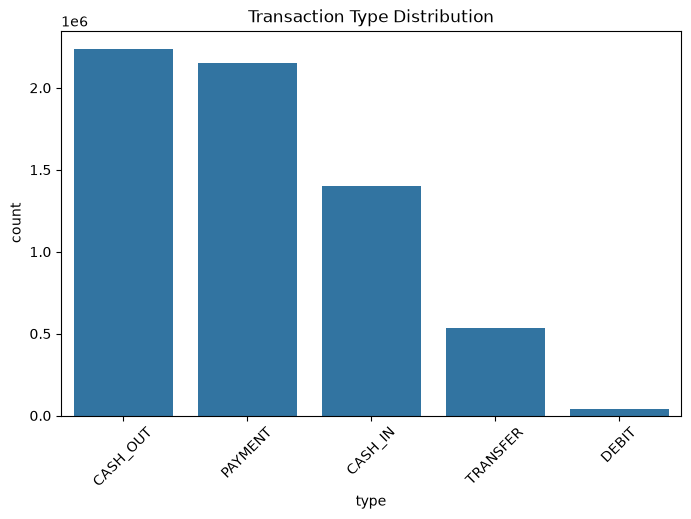

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)

plt.show()

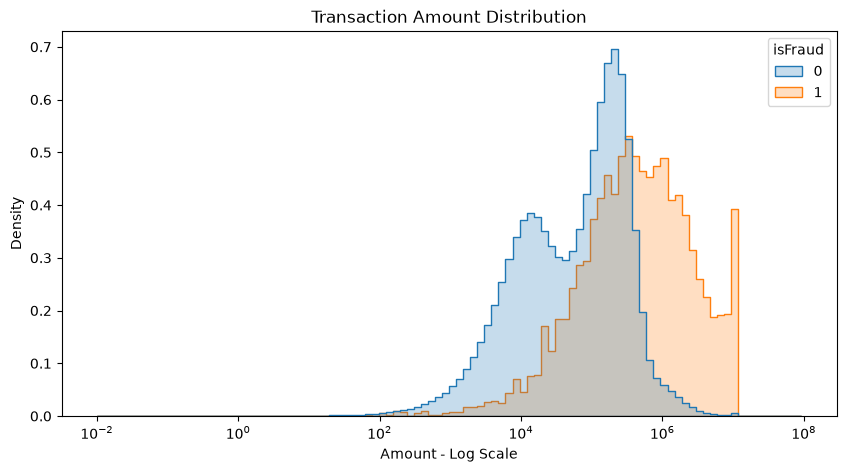

In [34]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    log_scale=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount - Log Scale")

plt.show()

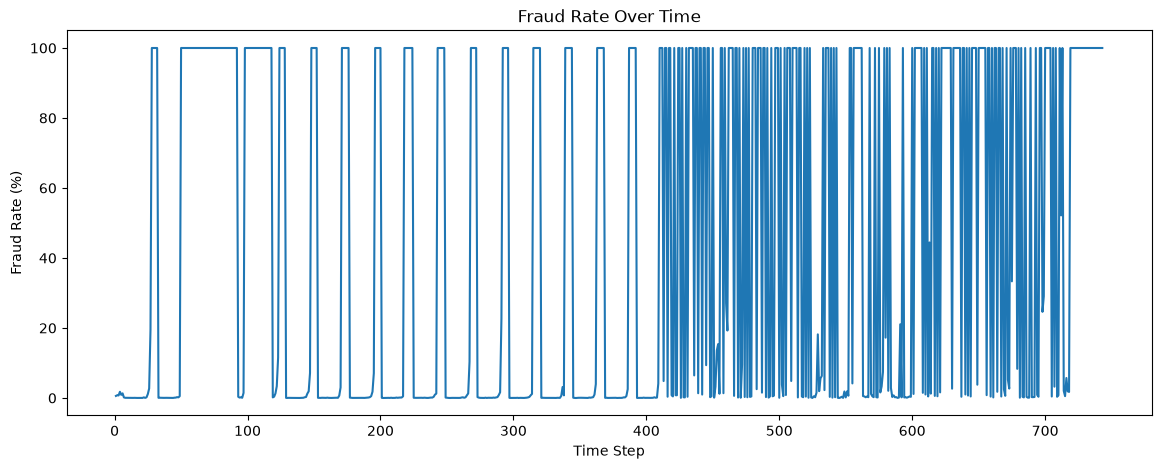

In [36]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
    .mean()
)

plt.figure(figsize=(14, 5))

fraud_by_step.mul(100).plot()

plt.title("Fraud Rate Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [37]:
sample_customer = df["nameOrig"].iloc[0]

customer_history = (
    df[df["nameOrig"] == sample_customer]
    .sort_values("step")
)

customer_history

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0


In [38]:
sequence_lengths = (
    df.groupby("nameOrig")
    .size()
)

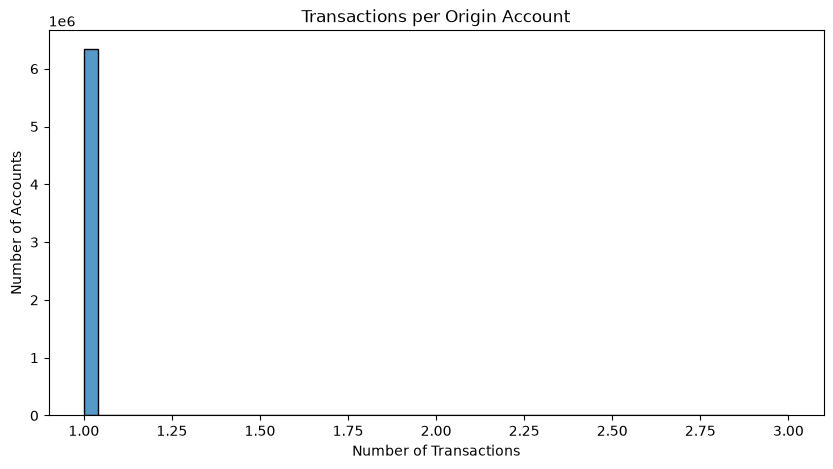

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sequence_lengths,
    bins=50
)

plt.title("Transactions per Origin Account")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Accounts")

plt.show()

In [40]:
df["origin_zero_before"] = (
    df["oldbalanceOrg"] == 0
)

df["origin_zero_after"] = (
    df["newbalanceOrig"] == 0
)

In [41]:
pd.crosstab(
    df["origin_zero_before"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
origin_zero_before,,
False,99.808177,0.191823
True,99.998050,0.001950


In [43]:
fraud_profile = {
    "total_transactions": len(df),
    "fraud_transactions": int(df["isFraud"].sum()),
    "fraud_rate": df["isFraud"].mean(),
    "unique_origins": df["nameOrig"].nunique(),
    "unique_destinations": df["nameDest"].nunique(),
    "transaction_types": df["type"].nunique(),
    "time_steps": df["step"].nunique(),
}

fraud_profile

{'total_transactions': 6362620,
 'fraud_transactions': 8213,
 'fraud_rate': np.float64(0.001290820448180152),
 'unique_origins': 6353307,
 'unique_destinations': 2722362,
 'transaction_types': 5,
 'time_steps': 743}

In [44]:
df["isFlaggedFraud"].value_counts()

pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"]
)

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [45]:
fraud_type_analysis = (
    df.groupby("type")
      .agg(
          transactions=("isFraud", "count"),
          fraud_transactions=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
)

fraud_type_analysis

,transactions,fraud_transactions,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


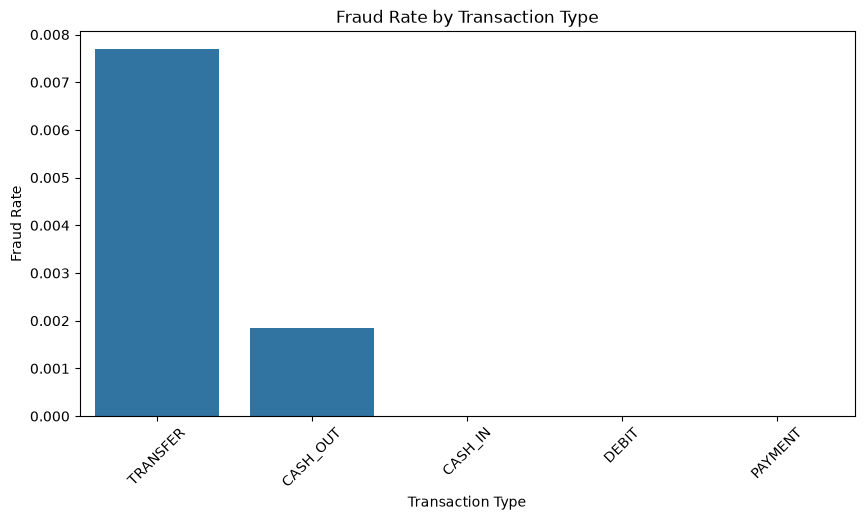

In [46]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_type_analysis.reset_index(),
    x="type",
    y="fraud_rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)
plt.show()

In [49]:
fraud_customers = df.loc[
    df["isFraud"] == 1,
    "nameOrig"
].nunique()

total_customers = df["nameOrig"].nunique()

print("Total origin accounts:", total_customers)
print("Origin accounts involved in fraud:", fraud_customers)

Total origin accounts: 6353307
Origin accounts involved in fraud: 8213


In [50]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr = df[numeric_cols].corr()

corr["isFraud"].sort_values(
    ascending=False
)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

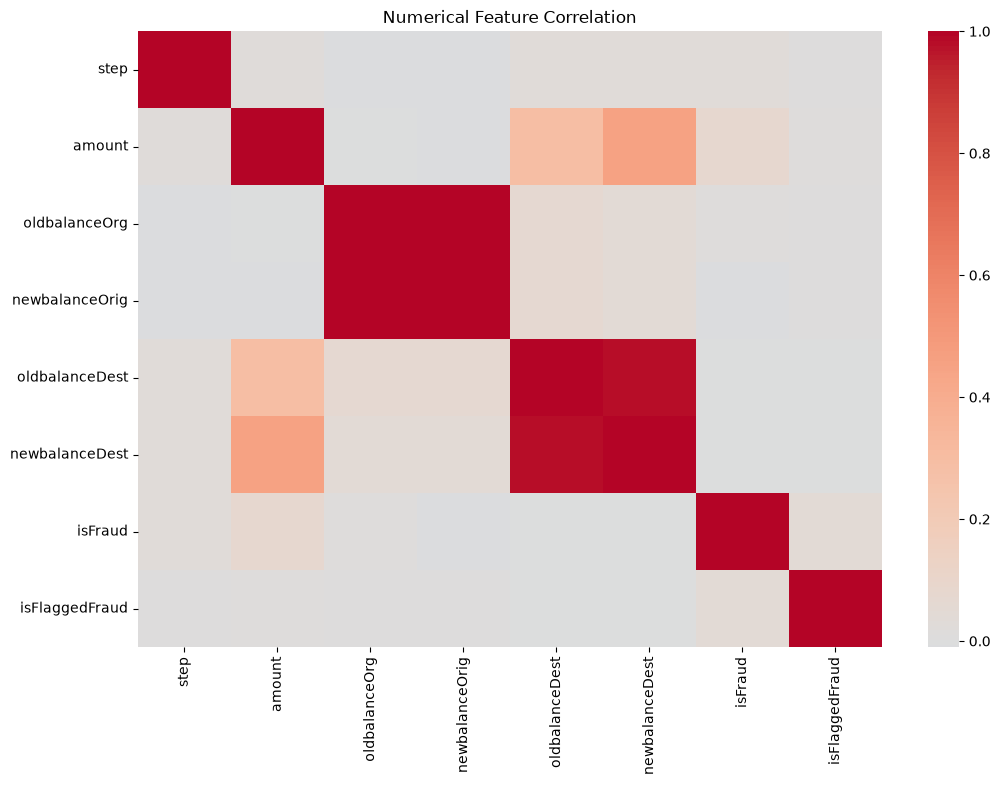

In [51]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.show()

In [ ]:
# # EDA Findings

# ## 1. Dataset

# - Number of transactions:
# - Number of features:
# - Missing values:
# - Duplicate rows:
# - Unique origin accounts:
# - Unique destination accounts:
# - Time steps:

# ## 2. Fraud Distribution

# - Fraud transactions:
# - Normal transactions:
# - Fraud percentage:
# - Imbalance ratio:

# ## 3. Transaction Type

# - Most common transaction type:
# - Transaction type with highest fraud rate:
# - Transaction type with lowest fraud rate:

# ## 4. Transaction Amount

# - Median normal amount:
# - Median fraud amount:
# - Mean normal amount:
# - Mean fraud amount:
# - Amount relationship with fraud:

# ## 5. Temporal Behavior

# - Time range:
# - Highest fraud-rate hours:
# - Evidence of temporal patterns:

# ## 6. Customer Behavior

# - Median transactions per customer:
# - 90th percentile:
# - 99th percentile:
# - Customers with >= 20 transactions:
# - Fraud concentration:

# ## 7. Balance Behavior

# - Origin balance anomalies:
# - Destination balance anomalies:
# - Potential balance-derived features:

# ## 8. Leakage Investigation

# - isFlaggedFraud:
# - Other potential leakage:

# ## 9. Candidate Features

# ### Transaction Features

# - amount
# - type
# - hour

# ### Balance Features

# - origin_balance_delta
# - destination_balance_delta
# - origin_balance_error
# - destination_balance_error

# ### Customer Features

# - transaction_count
# - average_amount
# - transaction_velocity

# ### Sequence Features

# - previous_transactions
# - sequence_length
# - temporal ordering

# ## 10. Modeling Implications

# ### XGBoost

# Tabular transaction + behavioral aggregate features.

# ### LSTM

# Ordered customer transaction history.

# ### Transformer

# Ordered transaction sequence with self-attention.

# ### Ensemble

# Combine calibrated model probabilities through the Risk Engine.